<span style="color:#44f;font-weight:bold;">Codes for CNS2025: Lecture 12</span>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Stimulus correlation function
$$ \tilde{Q}_{ss}\left(\vec{\kappa}\right) \propto
\frac{\exp\left(-\alpha\left|\vec\kappa\right|\right)}
{\left|\vec\kappa\right|^2+\kappa_0^2} $$

## Optimal kernel with noise
$$ \left|\tilde{D}_\mathrm{s}\left(\vec\kappa\right)\right|
\propto \frac{\sqrt{\tilde{Q}_{ss}\left(\vec\kappa\right)}}
{\tilde{Q}_{ss}\left(\vec\kappa\right)
+\tilde{Q}_{\eta\eta}\left(\vec\kappa\right)}
$$

In [2]:
ialpha = 0.16 # Inverse of alpha
kappa0 = 0.16 # kappa_0
qee = 0.05    # Noise autocorrelation

# Power spectrum of stimulus
def Qss(k):
    return np.exp(-np.abs(k)/ialpha)/(k**2+kappa0**2) 

# Optimal kernel in momentum space
def Ds_eta(k,qee):
    Q0 = Qss(0)
    Qssk = Qss(k)
    return np.sqrt(Qssk)/(qee*Q0+Qssk)

# Normalize array by its maximum
def normax(a):
    return a/np.max(a)

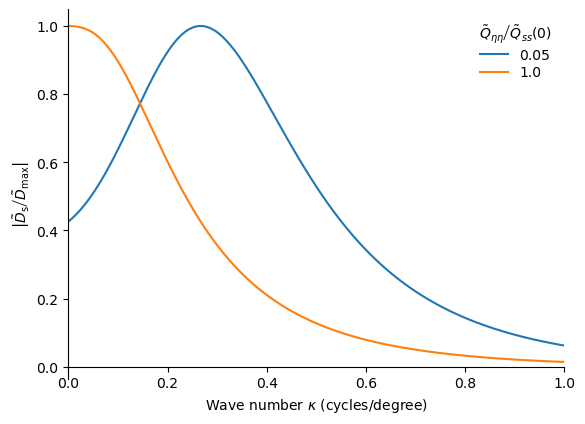

In [3]:
kps = np.linspace(0,1,257)
f = plt.figure()
a = plt.axes()
a.plot(kps,normax(Ds_eta(kps,0.05)),label='0.05')
a.plot(kps,normax(Ds_eta(kps,1.0)),label='1.0')
a.spines['bottom'].set_position('zero')
a.spines['top'].set_color('none')
a.spines['right'].set_color('none')
a.set_xlim([0,1])
plt.legend(title=r'$\~Q_{\eta\eta}\left/\~Q_{ss}(0)\right.$',frameon=False,labelspacing=0.25)
plt.xlabel(r'Wave number $\kappa$ (cycles/degree)')
plt.ylabel(r'$\left|\tilde{D}_\mathrm{s}\left/\tilde{D}_{\max}\right.\right|$')
plt.show()

## Discretization

In [4]:
N = 4096 # Discretization points
K = np.sqrt(np.pi*N/2) # Bounds, this makes K==L
dk = 2*K/N # Resolution in momentum (dx = dk)
rk = np.arange(N) # Enumerating κ
rr = rk*2*K/N-K # All values of κ
kx = np.outer(rr,np.ones(N)) # x coordinate
ky = np.outer(np.ones(N),rr) # y coordinate
# Sum of enumerations of k
kki = np.outer(rk,np.ones(N))+np.outer(np.ones(N),rk)
kp = np.sqrt(kx**2+ky**2) # Magnitude of k

## 3D plot in the momentum space

In [5]:
from mpl_toolkits.mplot3d import Axes3D

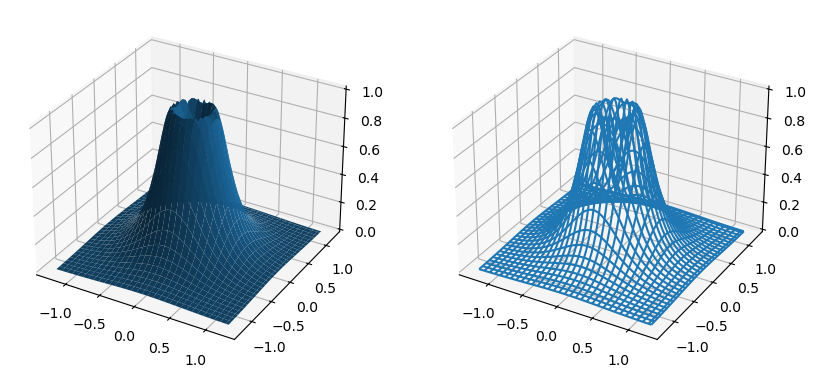

In [6]:
s = normax(Ds_eta(kp,0.05)) # Normalize
w = 32 # Index range to plot 

f = plt.figure(figsize=(10,5))
for p in [ # Make two plots
    f.add_subplot(1,2,1,projection='3d').plot_surface,
    f.add_subplot(1,2,2,projection='3d').plot_wireframe
]: p(
    kx[N//2-w:N//2+w,N//2-w:N//2+w],
    ky[N//2-w:N//2+w,N//2-w:N//2+w],
    s[N//2-w:N//2+w,N//2-w:N//2+w]
)
plt.show()

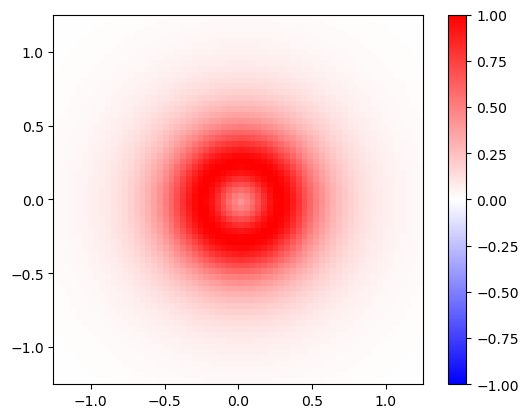

In [7]:
plt.figure()
plt.imshow(
    s[N//2-w:N//2+w,N//2-w:N//2+w],
    extent=(rr[N//2-w],rr[N//2+w],rr[N//2-w],rr[N//2+w]),
    cmap=plt.cm.bwr,vmin=-1,vmax=1
)
plt.colorbar()
plt.show()

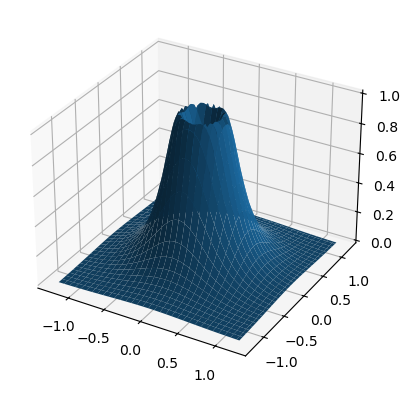

In [8]:
s = normax(Ds_eta(kp,0.05)) # Normalize
w = 32 # Index range to plot
f = plt.figure()
a = f.add_subplot(projection='3d')
a.plot_surface(
    kx[N//2-w:N//2+w,N//2-w:N//2+w],
    ky[N//2-w:N//2+w,N//2-w:N//2+w],
    s[N//2-w:N//2+w,N//2-w:N//2+w]
)
plt.show()

## Fourier transform back to real space

In [9]:
from numpy.fft import fft,fft2,fftshift

In [10]:
ds_l = Ds_eta(kp,0.05) # Low noise
ds_h = Ds_eta(kp,1.0)  # High noise

In [11]:
dsr_l = fft2(fftshift(ds_l)).real
dsr_h = fft2(fftshift(ds_h)).real

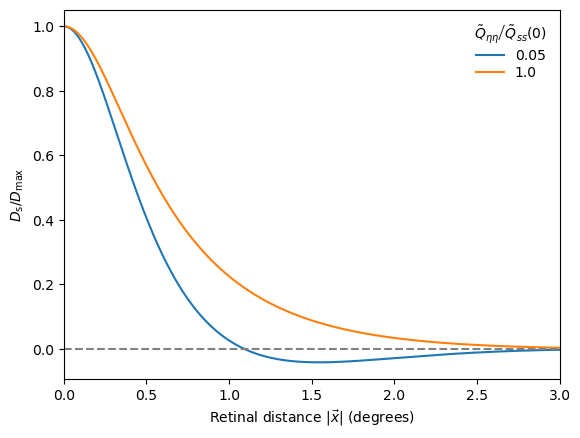

In [12]:
f = plt.figure()
kr = np.arange(1000)*dk/(2*np.pi) # Range of κ
plt.plot(kr,normax(dsr_l[0][:1000]),label='0.05')
plt.plot(kr,normax(dsr_h[0][:1000]),label='1.0')
plt.legend(title=r'$\~Q_{\eta\eta}\left/\~Q_{ss}(0)\right.$',frameon=False,labelspacing=0.25)
plt.hlines([0],0,3,linestyle='--',colors='gray')
plt.xlim(0,3)
plt.xlabel(r'Retinal distance $|\vec{x}|$ (degrees)')
plt.ylabel(r'$D_\mathrm{s}\left/D_\max\right.$')
plt.show()

In [13]:
flt_l = normax(fftshift(dsr_l))
flt_h = normax(fftshift(dsr_h))

In [14]:
ww = 400

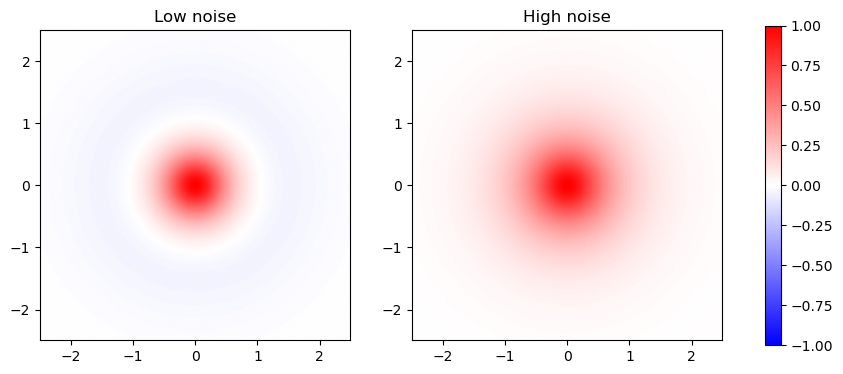

In [15]:
f,aa = plt.subplots(1,2,figsize=(11,5))
a = aa[0]
c = a.imshow(
    flt_l[N//2-ww:N//2+ww,N//2-ww:N//2+ww],
    extent=(-kr[ww],kr[ww],-kr[ww],kr[ww]),
    cmap=plt.cm.bwr,vmin=-1,vmax=1
)
a.set_title('Low noise')
a = aa[1]
a.imshow(
    flt_h[N//2-ww:N//2+ww,N//2-ww:N//2+ww],
    extent=(-kr[ww],kr[ww],-kr[ww],kr[ww]),
    cmap=plt.cm.bwr,vmin=-1,vmax=1
)
a.set_title('High noise')
plt.colorbar(c,ax=aa,shrink=0.83)
plt.show()

In [16]:
# Data extracted from Dong & Atick 1995
#   https://www.tandfonline.com/doi/full/10.1088/0954-898X_6_2_003
[sh_omega,sh_rate] = np.array([
    [ 0.50242809,  5.55405405],
    [ 1.00221171, 11.57142857],
    [ 2.00927468, 21.59073359],
    [ 4.01135024, 25.10617761],
    [ 8.0218268 , 19.54633205],
    [16.04190644,  2.02702703],
    [24.03248853,  1.56370656]
]).T

In [17]:
ws = np.exp(np.linspace(*np.log([0.1,50]),100))
wc = 5.5

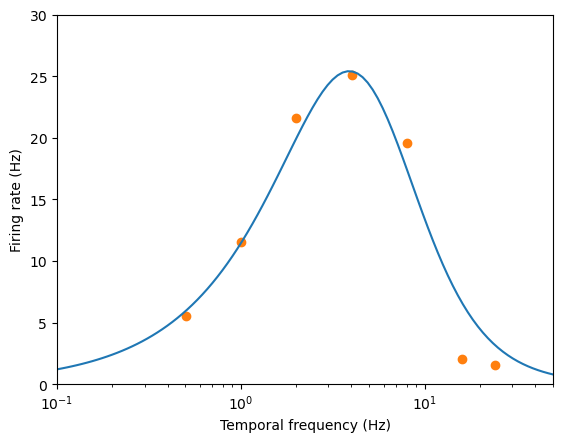

In [18]:
plt.figure()
plt.plot(ws,12*ws/(1+(ws/wc)**2)**1.5)
plt.scatter(sh_omega,sh_rate,c='C1')
plt.xscale('log')
plt.xlim(0.1,50)
plt.ylim(0,30)
plt.xlabel('Temporal frequency (Hz)')
plt.ylabel('Firing rate (Hz)')
plt.show()

## Fourier transform

Following the convention of the D&A
\begin{equation*}
  f(x) = \frac{1}{2\pi}\int_{-\infty}^\infty d\kappa e^{-i\kappa x} \tilde f(\kappa)
\end{equation*}
For the inverse transform, integrate $f(x)$ to get
\begin{align*}
    & \int_{-\infty}^\infty dx e^{i\kappa x}f(x)\\
  = \, & \int_{-\infty}^\infty dx e^{i\kappa x} \frac{1}{2\pi}\int_{-\infty}^\infty d\kappa' e^{-i\kappa' x} \tilde f(\kappa') \\
  = \, & \frac{1}{2\pi}\int_{-\infty}^\infty d\kappa' \tilde f(\kappa') \int_{-\infty}^\infty dx e^{i(\kappa-\kappa')x} \\
  = \, & \frac{1}{2\pi}\int_{-\infty}^\infty d\kappa' \tilde f(\kappa') 2\pi\delta(\kappa-\kappa') \\
  = \, & \tilde f(\kappa)
\end{align*}

\begin{align*}
   & \int_{-\infty}^\infty dx e^{i\kappa x} \\
 = & \lim_{L\rightarrow\infty}\int_{-L}^L dx e^{i\kappa x} \\
 = & \lim_{L\rightarrow\infty} \frac{1}{i\kappa} \left(e^{i\kappa L}- e^{-i\kappa L}\right) \\
 = & \lim_{L\rightarrow\infty} \frac{2}{\kappa} \sin(\kappa L)
\end{align*}

Consider the function $\sin(\kappa L)/\kappa$, for $\kappa\neq 0$, it is fast oscillating, thus,
when convolving with a smooth function, is indistinguishable from 0.

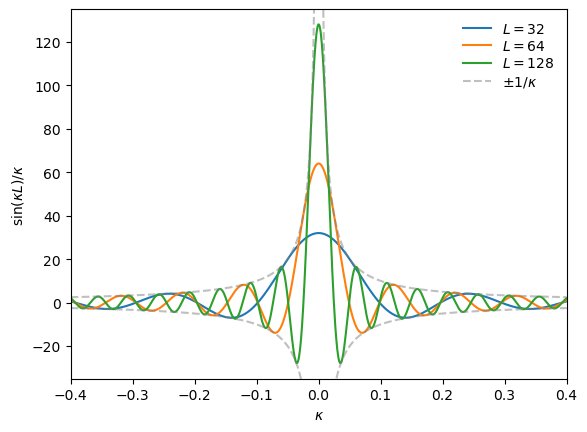

In [19]:
plt.figure()
ks = np.linspace(-0.4,0.4,1000)
for L in [32,64,128]:
    plt.plot(ks,np.sin(ks*L)/ks,label=f'$L={L}$')
# asymptote
plt.plot(ks,1/np.abs(ks),'--',color='gray',alpha=0.5,label=r'$\pm 1/\kappa$')
plt.plot(ks,-1/np.abs(ks),'--',color='gray',alpha=0.5)
plt.ylim(-35,135)
plt.xlim(-.4,.4)
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$\sin(\kappa L)/\kappa$')
plt.legend(frameon=False,labelspacing=0.25)
plt.show()

However, its improper, definite integral,
\begin{equation*}
  \int_{-\infty}^\infty d\kappa \frac{\sin(\kappa L)}{\kappa}
  = \int_{-\infty}^\infty d(\kappa L) \frac{\sin(\kappa L)}{\kappa L} = \pi
\end{equation*}
results in a finite value.
Therefore, in the limit $L\rightarrow\infty$, $\sin(\kappa L)/(\pi\kappa)$ satisfies
the required properties of a Dirac delta-function.
\begin{equation*}
\delta(\kappa) = \lim_{L\rightarrow\infty}\frac{\sin(\kappa L)}{\pi\kappa}
\end{equation*}
Consequently, we have
\begin{equation*}
 \int_{-\infty}^\infty dx e^{i\kappa x} = 2\pi\delta(\kappa)
\end{equation*}
as used above.

## Square pulse example
$$ f(x) = \begin{cases}
    1, & \text{ for } -1<x<1 \\
    0, & \text{ otherwise }
\end{cases} $$

In [20]:
def sq(x):
    return (x>-1)*(x<1)

In [21]:
L = 16
N = 512
K = np.pi*N/(2*L) # So that $2KL = \pi N$

In [22]:
dx = 2*L/N
dk = 2*K/N

In [23]:
xs = np.arange(N)*dx-L
ks = np.arange(N)*dk-K

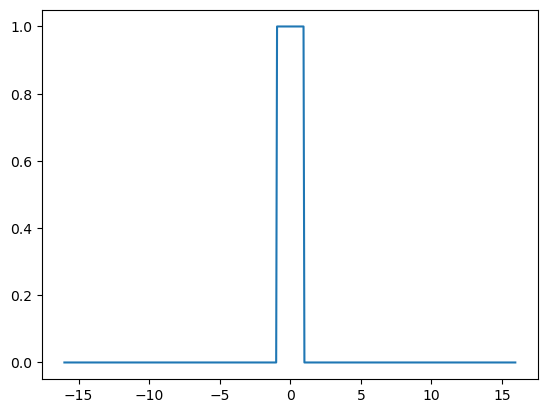

In [24]:
plt.figure()
plt.plot(xs,sq(xs))
plt.show()

### Use Riemann sum for the integral

In [25]:
fk0 = np.array([(dx*sq(xs)*np.exp(1j*k*xs)).sum() for k in ks])

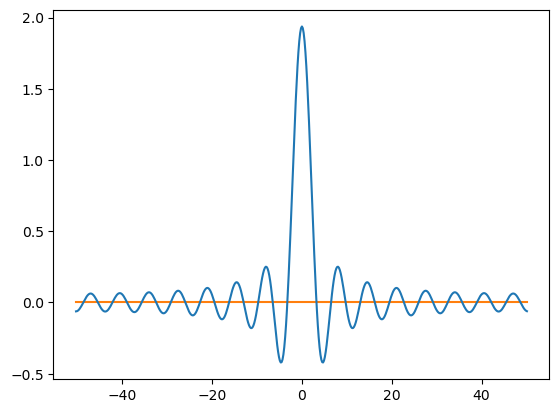

In [26]:
plt.figure()
plt.plot(ks,fk0.real)
plt.plot(ks,fk0.imag,zorder=-1)
plt.show()

### Use `scipy` for better accuracy

In [27]:
from scipy.integrate import quad

In [28]:
fk1 = np.array([quad(lambda x:sq(x)*np.exp(1j*k*x).real,-L,L,limit=100)[0] for k in ks])

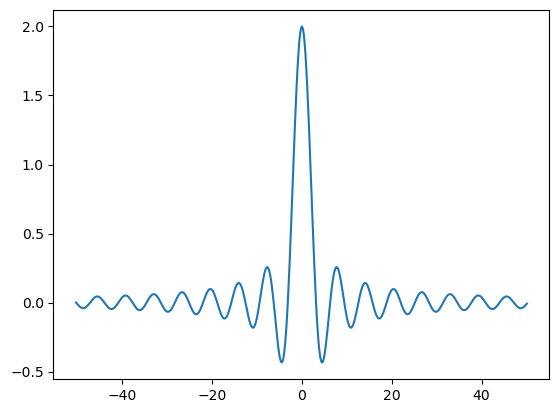

In [29]:
plt.figure()
plt.plot(ks,fk1)
plt.show()

### Use `fft`

In [30]:
fx = sq(xs)

In [31]:
fk2 = fftshift(fft(fftshift(dx*fx)))

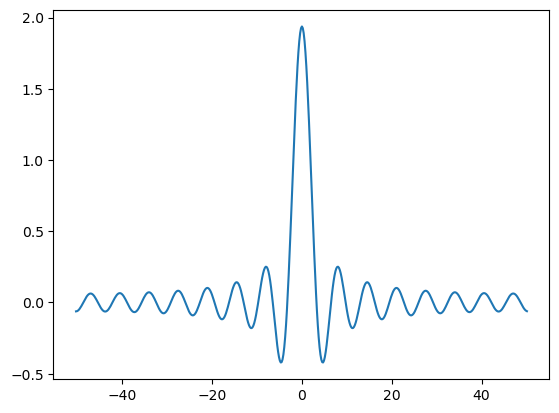

In [32]:
plt.plot(ks,fk2.real)
plt.show()

<hr>
<address style="color:#44f;font-style:italic;font-weight:bold;"><a href="https://cc.tir.tw/wk/2025cns">CNS2025</a></address>